# Assignment 3: Exploratory Data Analysis

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the Dataset

In [2]:
#Loading the individual Dataset
file_path = r'extracted_output/pizza_sales/'

files = {}
for file in os.listdir(file_path):
    files[file] = pd.read_csv(file_path + file, encoding='latin1')

In [3]:
#Inspecting Each datasets

for name, df in files.items():
    print("=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)
    display(df.head())

Dataset: orders.csv


,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


Dataset: order_details.csv


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


Dataset: pizzas.csv


,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


Dataset: pizza_types.csv


,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


###  Merging all the datasets into a single dataset

In [4]:
#Assigning each dataset to a variable

orders = files['orders.csv']
order_details = files['order_details.csv']
pizzas = files['pizzas.csv']
pizza_types = files['pizza_types.csv']



# Merge orders with order_details
df = pd.merge(
    orders,
    order_details,
    on='order_id',
    how='inner'
)

# Merge with pizzas
df = pd.merge(
    df,
    pizzas,
    on='pizza_id',
    how='inner'
)

# Merge with pizza_types
df = pd.merge(
    df,
    pizza_types,
    on='pizza_type_id',
    how='inner'
)

# Exploratory Data Analysis

In [5]:
#Inspecting the Shape of the Dataset
df.shape

(48620, 12)

In [6]:
#Overview of the Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  int64  
 1   date              48620 non-null  object 
 2   time              48620 non-null  object 
 3   order_details_id  48620 non-null  int64  
 4   pizza_id          48620 non-null  object 
 5   quantity          48620 non-null  int64  
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [7]:
#Checking for missing values
df.isna().sum()

order_id            0
date                0
time                0
order_details_id    0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [8]:
#Inspecting Unique Element in the Dataset
for col in df.columns:
    print("=" * 60)
    print(f'Column Name: {col}')
    print("=" * 60)
    display(df[col].value_counts())

Column Name: order_id


order_id
18845    21
10760    21
18280    15
21158    15
17464    15
         ..
10351     1
10355     1
10357     1
10360     1
21350     1
Name: count, Length: 21350, dtype: int64

Column Name: date


date
2015-11-26    261
2015-11-27    259
2015-10-15    258
2015-07-04    233
2015-07-03    207
             ... 
2015-12-27     87
2015-11-22     82
2015-12-29     77
2015-03-22     76
2015-12-30     73
Name: count, Length: 358, dtype: int64

Column Name: time


...

name
The Classic Deluxe Pizza                      2416
The Barbecue Chicken Pizza                    2372
The Hawaiian Pizza                            2370
The Pepperoni Pizza                           2369
The Thai Chicken Pizza                        2315
The California Chicken Pizza                  2302
The Sicilian Pizza                            1887
The Spicy Italian Pizza                       1887
The Southwest Chicken Pizza                   1885
The Four Cheese Pizza                         1850
The Italian Supreme Pizza                     1849
The Big Meat Pizza                            1811
The Vegetables + Vegetables Pizza             1510
The Mexicana Pizza                            1456
The Napolitana Pizza                          1451
The Spinach and Feta Pizza                    1432
The Prosciutto and Arugula Pizza              1428
The Pepper Salami Pizza                       1422
The Italian Capocollo Pizza                   1414
The Greek Pizza           

Column Name: category


category
Classic    14579
Supreme    11777
Veggie     11449
Chicken    10815
Name: count, dtype: int64

Column Name: ingredients


ingredients
Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon                                                 2416
Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce                  2372
Sliced Ham, Pineapple, Mozzarella Cheese                                                             2370
Mozzarella Cheese, Pepperoni                                                                         2369
Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce                                   2315
Chicken, Artichoke, Spinach, Garlic, Jalapeno Peppers, Fontina Cheese, Gouda Cheese                  2302
Coarse Sicilian Salami, Tomatoes, Green Olives, Luganega Sausage, Onions, Garlic                     1887
Capocollo, Tomatoes, Goat Cheese, Artichokes, Peperoncini verdi, Garlic                              1887
Chicken, Tomatoes, Red Peppers, Red Onions, Jalapeno Peppers, Corn, Cilantro, Chipotle Sauce         1885
Ricotta Cheese, Gorgonzola Piccant

In [9]:
#Checking for duplicates
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
48615    False
48616    False
48617    False
48618    False
48619    False
Length: 48620, dtype: bool

### Preliminary Findings
- No Missing values and no duplicate values
- All features have appropraite data type except for date and time features
- Needs to convert the date and time features to the appropraite data type

In [10]:
#Changing the data and time feature to the right data type

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Convert time column to time datatype
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time

## Questions

### 1.	What is the total revenue/sales?

In [11]:
# Create a revenue column
df['revenue'] = df['quantity'] * df['price']

# Calculate total revenue
total_revenue = df['revenue'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $817,860.05


### 2.	Find the total quantity sold.

In [12]:
#Calculating the Total Quantity Sold
total_quantity_sold = df['quantity'].sum()
print(f'Total Quantity Sold = {total_quantity_sold}')

Total Quantity Sold = 49574


### 3.	Find the total orders.

In [13]:
#Finding the total Number of Unique Order placed
total_orders = df['order_id'].nunique()

print("Total Orders:", total_orders)

Total Orders: 21350


### 4.	How many pizza types do they sell?

In [14]:
#Number of pizza types they sold
pizza_types = df['pizza_type_id'].nunique()
print(f"The restaurant sells {pizza_types} different pizza types.")

The restaurant sells 32 different pizza types.


### 5.	Find the average price of the pizzas.

In [15]:
#calculating the Average Price of pizzas

average_price = df['price'].mean()

print(f"Average Price: ${average_price:.2f}")

Average Price: $16.49


### 6.	What are the peak hours of sales?

In [16]:
# Extract the hour from the time column
df['hour'] = df['time'].apply(lambda x: x.hour)

# Total revenue by hour
peak_hours = (
    df.groupby('hour')['revenue']
      .sum()
      .reset_index()
      .sort_values(by='revenue', ascending=False)
)

peak_hours

,hour,revenue
3,12,111877.90
4,13,106065.70
9,18,89296.85
8,17,86237.45
10,19,72628.90
7,16,70055.40
5,14,59201.40
11,20,58215.40
6,15,52992.30
2,11,44935.80


### 7.	Find the total sales made on each day of the week. Which day of the week is when sales are made the most?

In [17]:
#Extracting the days of the week into a new column
df['day_of_week'] = df['date'].dt.day_name()


#Grouping the day per day of the week
sales_by_day = (df.groupby('day_of_week')['revenue'].sum().reset_index())


sales_by_day

,day_of_week,revenue
0,Friday,136073.90
1,Monday,107329.55
2,Saturday,123182.40
3,Sunday,99203.50
4,Thursday,123528.50
5,Tuesday,114133.80
6,Wednesday,114408.40


In [18]:
#Finding days with the highest sales
highest_sales_day = (sales_by_day.sort_values('revenue', ascending=False)
                .head(1))

highest_sales_day

,day_of_week,revenue
0,Friday,136073.9


### 8.	Find the top 5 bestselling pizzas.

In [19]:
#Finding the top 5 bestselling pizzas by considering the quantity of each pizzas sold
top_5_pizzas = (df.groupby('name')['quantity'].sum()
      .reset_index()
      .sort_values(by='quantity', ascending=False)
      .head(5)
)

top_5_pizzas

,name,quantity
7,The Classic Deluxe Pizza,2453
0,The Barbecue Chicken Pizza,2432
12,The Hawaiian Pizza,2422
20,The Pepperoni Pizza,2418
30,The Thai Chicken Pizza,2371


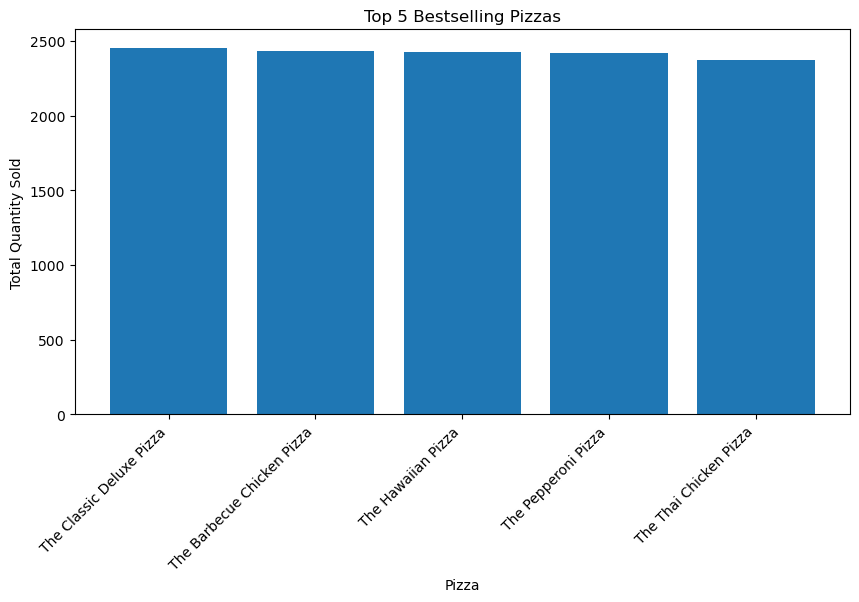

In [20]:
#Visualizing the top 5 best selling pizzas

plt.figure(figsize=(10,5))

plt.bar(top_5_pizzas['name'], top_5_pizzas['quantity'])

plt.title('Top 5 Bestselling Pizzas')
plt.xlabel('Pizza')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')

plt.show()

### 9.	Find the sales made in each month. Any trend noticeable?

In [21]:
#Extracting the month from the dataset
df['month'] = df['date'].dt.month_name()


months = ['January', 'February', 'March', 'April','May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']

monthly_sales = (df.groupby('month')['revenue'].sum().reindex(months).reset_index())

#Sorting the values in descending order

#monthly_sales = monthly_sales.sort_values(by='revenue', ascending=False)

monthly_sales

,month,revenue
0,January,69793.30
1,February,65159.60
2,March,70397.10
3,April,68736.80
4,May,71402.75
5,June,68230.20
6,July,72557.90
7,August,68278.25
8,September,64180.05
9,October,64027.60


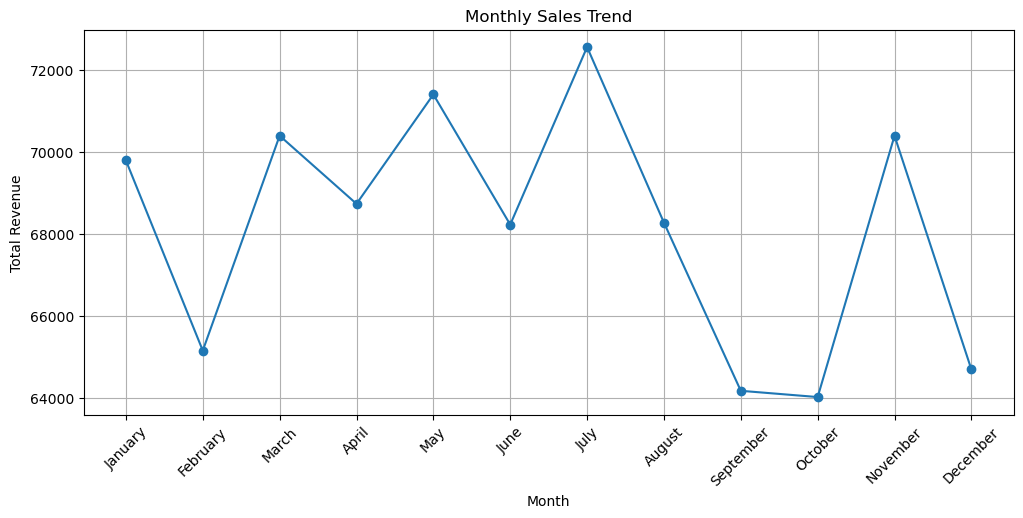

In [22]:
#Visualizing the trends
plt.figure(figsize=(12,5))

plt.plot(monthly_sales['month'],
         monthly_sales['revenue'],
         marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

#### Observation
The monthly sales trend shows a fluctuating sales pattern across the year. Revenue reached its highest level in July and its lowest in October. The absence of a steady upward or downward trend suggests that sales performance was affected by periodic changes in customer purchasing behavior, therefore it is important to investigate the what is driving strong performance in peak months and weaker performance during low-sales periods.

### 10.	Are there pizza types that are not doing well on the menu?

In [23]:
#Pizza types that are not doing well on the menu by quantity
bottom_5_pizzas = df.groupby('name')['quantity'].sum().reset_index().sort_values(by='quantity', ascending=True).head(5)

bottom_5_pizzas

,name,quantity
2,The Brie Carre Pizza,490
16,The Mediterranean Pizza,934
3,The Calabrese Pizza,937
28,The Spinach Supreme Pizza,950
24,The Soppressata Pizza,961


In [24]:
#Pizza types that are not doing well on the menu by Revenue
bottom_5_pizzas = df.groupby('name')['revenue'].sum().reset_index().sort_values(by='revenue', ascending=True).head(5)

bottom_5_pizzas

,name,revenue
2,The Brie Carre Pizza,11588.50
11,The Green Garden Pizza,13955.75
28,The Spinach Supreme Pizza,15277.75
16,The Mediterranean Pizza,15360.50
27,The Spinach Pesto Pizza,15596.00


### Which pizza category generates the most revenue?

In [25]:
category_revenue = (
    df.groupby('category')['revenue']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_revenue

,category,revenue
0,Classic,220053.10
1,Supreme,208197.00
2,Chicken,195919.50
3,Veggie,193690.45


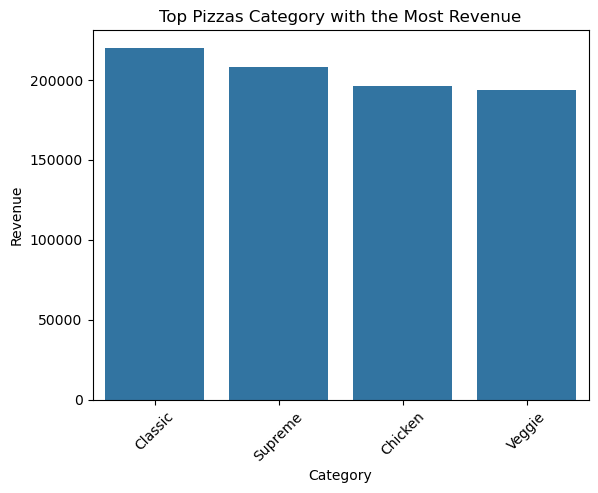

In [26]:
sns.barplot(data=category_revenue, x='category', y='revenue')

plt.title('Top Pizzas Category with the Most Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

### Which Pizza Size is Most Preferred?

In [27]:
size_sales = (
    df.groupby('size')['quantity']
      .sum()
      .reset_index()
      .sort_values(by='quantity', ascending=False)
)

size_sales

,size,quantity
0,L,18956
1,M,15635
2,S,14403
3,XL,552
4,XXL,28


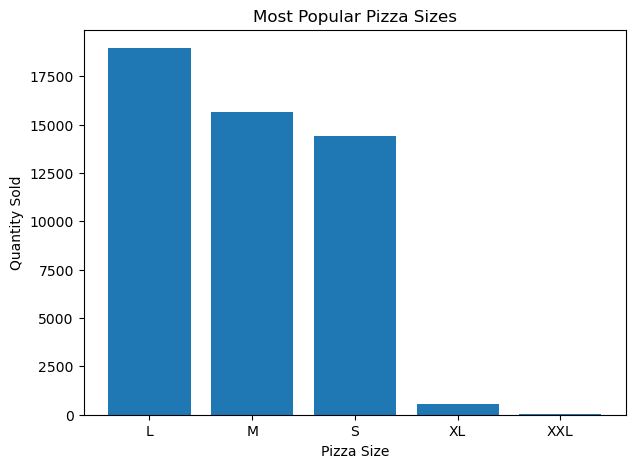

In [28]:
plt.figure(figsize=(7,5))

plt.bar(size_sales['size'],
        size_sales['quantity'])

plt.title('Most Popular Pizza Sizes')
plt.xlabel('Pizza Size')
plt.ylabel('Quantity Sold')

plt.show()

### Which Pizza Generated the Highest Revenue?

In [29]:
top_revenue_pizzas = (
    df.groupby('name')['revenue']
      .sum()
      .reset_index()
      .sort_values(by='revenue', ascending=False)
      .head(10)
)

top_revenue_pizzas

,name,revenue
30,The Thai Chicken Pizza,43434.25
0,The Barbecue Chicken Pizza,42768.00
4,The California Chicken Pizza,41409.50
7,The Classic Deluxe Pizza,38180.50
26,The Spicy Italian Pizza,34831.25
25,The Southwest Chicken Pizza,34705.75
14,The Italian Supreme Pizza,33476.75
12,The Hawaiian Pizza,32273.25
9,The Four Cheese Pizza,32265.70
23,The Sicilian Pizza,30940.50


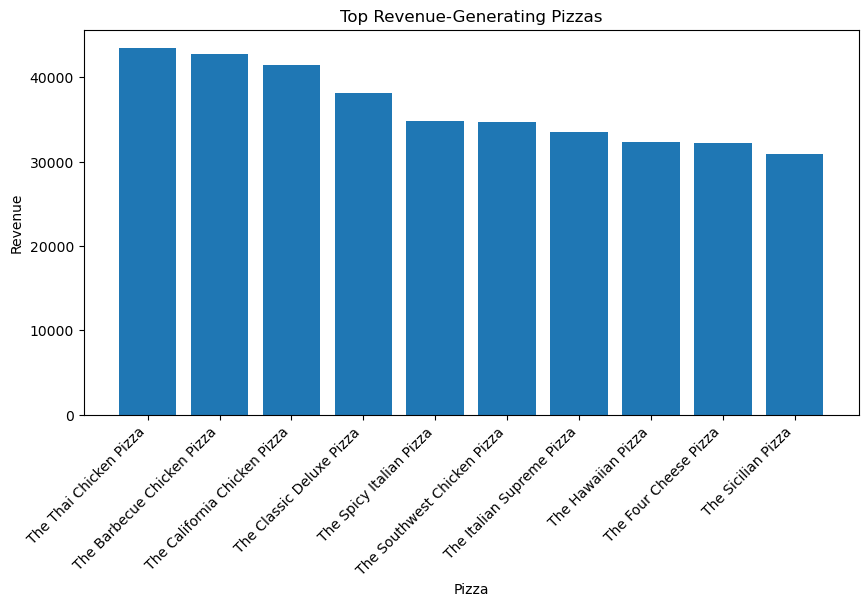

In [30]:
#Visualizing the insights
plt.figure(figsize=(10,5))

plt.bar(top_revenue_pizzas['name'],
        top_revenue_pizzas['revenue'])

plt.title('Top Revenue-Generating Pizzas')
plt.xlabel('Pizza')
plt.ylabel('Revenue')

plt.xticks(rotation=45, ha='right')

plt.show()

### Conclusion

The exploratory data analysis showed that the restaurant generated a total revenue of #817,860.5 from 21,350 customer orders, with a total of 49,574 pizzas sold at an average price of #16.51 per pizza. Sales were highest during the peak business hours of 12 and reached their maximum on Friday, while July recorded the highest monthly revenue. The The Classic Deluxe Pizza emerged as the bestselling pizza, whereas The Brie Carre Pizza recorded the lowest sales. Furthermore, Classic was the highest-performing pizza category, L was the most preferred pizza size, and The Thai Chicken Pizza generated the highest overall revenue. These findings provide valuable insights into customer purchasing behaviour and can support informed decisions on inventory management, staffing, pricing, promotions, and menu optimization.